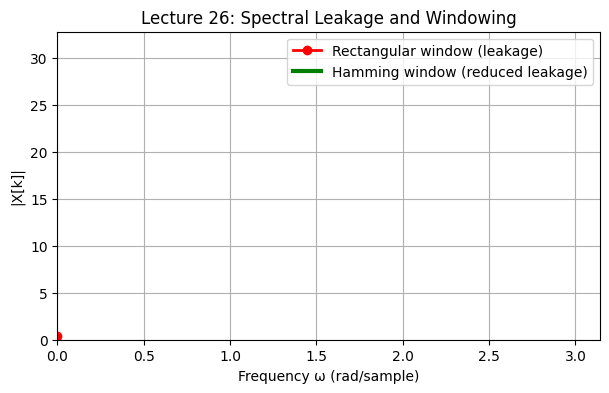

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 26: Spectral Leakage & Windowing
# -----------------------------

# Time-domain signal (not on a DFT bin)
N = 64
n = np.arange(N)
omega0 = 0.37 * np.pi
x = np.cos(omega0 * n)

# Windows
rect = np.ones(N)
ham  = np.hamming(N)

# Windowed signals
x_rect = x * rect
x_ham  = x * ham

# FFTs
X_rect = np.abs(np.fft.fft(x_rect))
X_ham  = np.abs(np.fft.fft(x_ham))

# Frequency axis
w = np.linspace(0, 2*np.pi, N, endpoint=False)

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, np.pi)
ax.set_ylim(0, max(X_rect) + 2)
ax.grid(True)
ax.set_title("Lecture 26: Spectral Leakage and Windowing")
ax.set_xlabel("Frequency ω (rad/sample)")
ax.set_ylabel("|X[k]|")

# Animated plots
rect_line, = ax.plot([], [], 'r-o', lw=2,
                     label="Rectangular window (leakage)")
ham_line,  = ax.plot([], [], 'g', lw=3,
                     label="Hamming window (reduced leakage)")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture‑9 style)
# -----------------------------
def update(frame):
    bins = frame + 1
    rect_line.set_data(w[:bins], X_rect[:bins])
    ham_line.set_data(w[:bins], X_ham[:bins])
    return rect_line, ham_line

anim = FuncAnimation(
    fig,
    update,
    frames=N//2,
    interval=350
)

HTML(anim.to_jshtml())